# Unsupervised Learning: Trade&Ahead

**Marks: 60**

### Context

The stock market has consistently proven to be a good place to invest in and save for the future. There are a lot of compelling reasons to invest in stocks. It can help in fighting inflation, create wealth, and also provides some tax benefits. Good steady returns on investments over a long period of time can also grow a lot more than seems possible. Also, thanks to the power of compound interest, the earlier one starts investing, the larger the corpus one can have for retirement. Overall, investing in stocks can help meet life's financial aspirations.

It is important to maintain a diversified portfolio when investing in stocks in order to maximise earnings under any market condition. Having a diversified portfolio tends to yield higher returns and face lower risk by tempering potential losses when the market is down. It is often easy to get lost in a sea of financial metrics to analyze while determining the worth of a stock, and doing the same for a multitude of stocks to identify the right picks for an individual can be a tedious task. By doing a cluster analysis, one can identify stocks that exhibit similar characteristics and ones which exhibit minimum correlation. This will help investors better analyze stocks across different market segments and help protect against risks that could make the portfolio vulnerable to losses.


### Objective

Trade&Ahead is a financial consultancy firm who provide their customers with personalized investment strategies. They have hired you as a Data Scientist and provided you with data comprising stock price and some financial indicators for a few companies listed under the New York Stock Exchange. They have assigned you the tasks of analyzing the data, grouping the stocks based on the attributes provided, and sharing insights about the characteristics of each group.

### Data Dictionary

- Ticker Symbol: An abbreviation used to uniquely identify publicly traded shares of a particular stock on a particular stock market
- Company: Name of the company
- GICS Sector: The specific economic sector assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- GICS Sub Industry: The specific sub-industry group assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- Current Price: Current stock price in dollars
- Price Change: Percentage change in the stock price in 13 weeks
- Volatility: Standard deviation of the stock price over the past 13 weeks
- ROE: A measure of financial performance calculated by dividing net income by shareholders' equity (shareholders' equity is equal to a company's assets minus its debt)
- Cash Ratio: The ratio of a  company's total reserves of cash and cash equivalents to its total current liabilities
- Net Cash Flow: The difference between a company's cash inflows and outflows (in dollars)
- Net Income: Revenues minus expenses, interest, and taxes (in dollars)
- Earnings Per Share: Company's net profit divided by the number of common shares it has outstanding (in dollars)
- Estimated Shares Outstanding: Company's stock currently held by all its shareholders
- P/E Ratio: Ratio of the company's current stock price to the earnings per share 
- P/B Ratio: Ratio of the company's stock price per share by its book value per share (book value of a company is the net difference between that company's total assets and total liabilities)

## Importing necessary libraries and data

In [1]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist, pdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to perform hierarchical clustering, compute cophenetic correlation, and create dendrograms
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet

# to perform PCA
from sklearn.decomposition import PCA

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

#format numeric data for easier readability
pd.set_option(
    "display.float_format", lambda x: "%.2f" % x
)  # to display numbers rounded off to 2 decimal places

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# To supress warnings
import warnings
warnings.filterwarnings("ignore")

## Data Overview

### Observations

In [2]:
data = pd.read_csv('stock_data.csv')

In [3]:
# Making a copy of dataset as safe method

df = data.copy()

In [4]:
df.sample (n=5,random_state=1)

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
102,DVN,Devon Energy Corp.,Energy,Oil & Gas Exploration & Production,32.00,-15.48,2.92,205,70,830000000,-14454000000,-35.55,406582278.50,93.09,1.79
125,FB,Facebook,Information Technology,Internet Software & Services,104.66,16.22,1.32,8,958,592000000,3669000000,1.31,2800763359.00,79.89,5.88
11,AIV,Apartment Investment & Mgmt,Real Estate,REITs,40.03,7.58,1.16,15,47,21818000,248710000,1.52,163625000.00,26.34,-1.27
248,PG,Procter & Gamble,Consumer Staples,Personal Products,79.41,10.66,0.81,17,129,160383000,636056000,3.28,491391569.00,24.07,-2.26
238,OXY,Occidental Petroleum,Energy,Oil & Gas Exploration & Production,67.61,0.87,1.59,32,64,-588000000,-7829000000,-10.23,765298142.70,93.09,3.35


In [5]:
df.shape

(340, 15)

***Jonathan's Comments: There are 340 rows and 15 columns on the dataset***

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticker Symbol                 340 non-null    object 
 1   Security                      340 non-null    object 
 2   GICS Sector                   340 non-null    object 
 3   GICS Sub Industry             340 non-null    object 
 4   Current Price                 340 non-null    float64
 5   Price Change                  340 non-null    float64
 6   Volatility                    340 non-null    float64
 7   ROE                           340 non-null    int64  
 8   Cash Ratio                    340 non-null    int64  
 9   Net Cash Flow                 340 non-null    int64  
 10  Net Income                    340 non-null    int64  
 11  Earnings Per Share            340 non-null    float64
 12  Estimated Shares Outstanding  340 non-null    float64
 13  P/E R

***Jonathan's Comments: There are not null values on the dataset, missing values treatment will not be necessary*** 

In [7]:
df.duplicated().sum()

0

***Jonathan's Comments: Dataset without duplicated values*** 

In [8]:
# Converting columns with object datatype to category
for col in df.columns[df.dtypes=='object']:
    df[col] = df[col].astype('category')

In [9]:
# Ticker Symbol is dropped since is not needed to further analysis
df.drop("Ticker Symbol", axis=1, inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Security                      340 non-null    category
 1   GICS Sector                   340 non-null    category
 2   GICS Sub Industry             340 non-null    category
 3   Current Price                 340 non-null    float64 
 4   Price Change                  340 non-null    float64 
 5   Volatility                    340 non-null    float64 
 6   ROE                           340 non-null    int64   
 7   Cash Ratio                    340 non-null    int64   
 8   Net Cash Flow                 340 non-null    int64   
 9   Net Income                    340 non-null    int64   
 10  Earnings Per Share            340 non-null    float64 
 11  Estimated Shares Outstanding  340 non-null    float64 
 12  P/E Ratio                     340 non-null    floa

***Jonathan's Comments: Dataset is ready to be processed and analysed*** 

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

In [11]:
# function to plot a boxplot and a histogram along the same scale

def histogram_boxplot(data, feature, figsize=(16, 6), kde=False, bins=None, hue=None):
    """
    Combines boxplot and histogram

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (16,6))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True,
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter",
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [12]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=12)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="viridis",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

## Questions:

## 1. What does the distribution of stock prices look like?

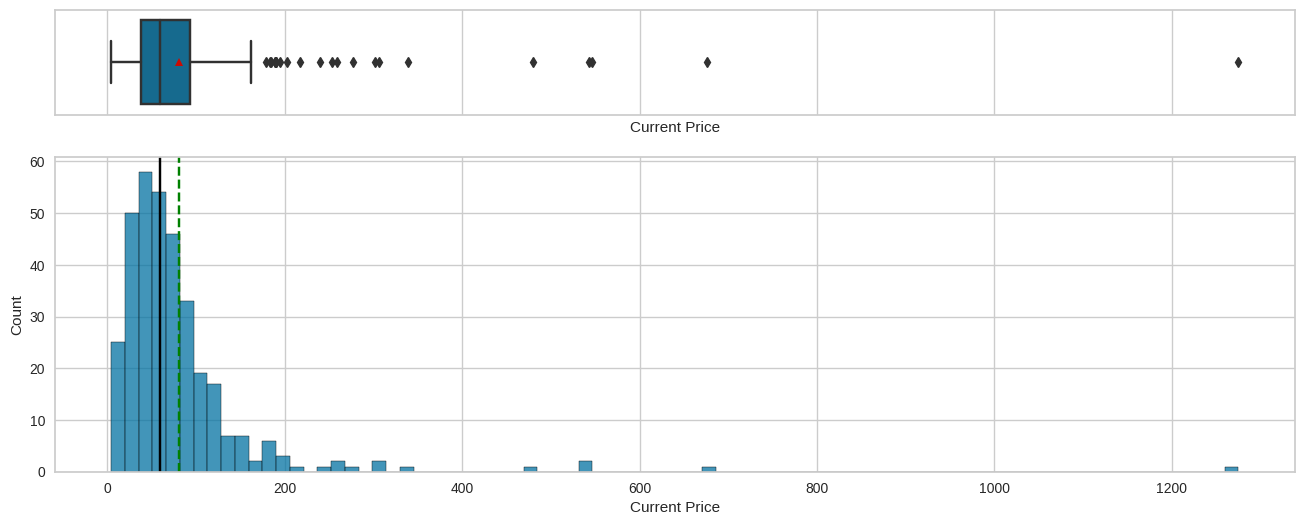

In [13]:
histogram_boxplot(df,'Current Price')

**Jonathan's Comments:** 
- The distribution of stock prices is heavily right skewed


## 2. The stocks of which economic sector have seen the maximum price increase on average?

In [14]:
df.groupby('GICS Sector')['Price Change'].mean().sort_values()

GICS Sector
Energy                        -10.23
Utilities                       0.80
Industrials                     2.83
Financials                      3.87
Materials                       5.59
Consumer Discretionary          5.85
Real Estate                     6.21
Telecommunications Services     6.96
Information Technology          7.22
Consumer Staples                8.68
Health Care                     9.59
Name: Price Change, dtype: float64

**Jonathan's Comments:** 
- Healt care stocks are those that had the maximum price increase on average with 9.59 


## 3. How are the different variables correlated with each other?

In [15]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

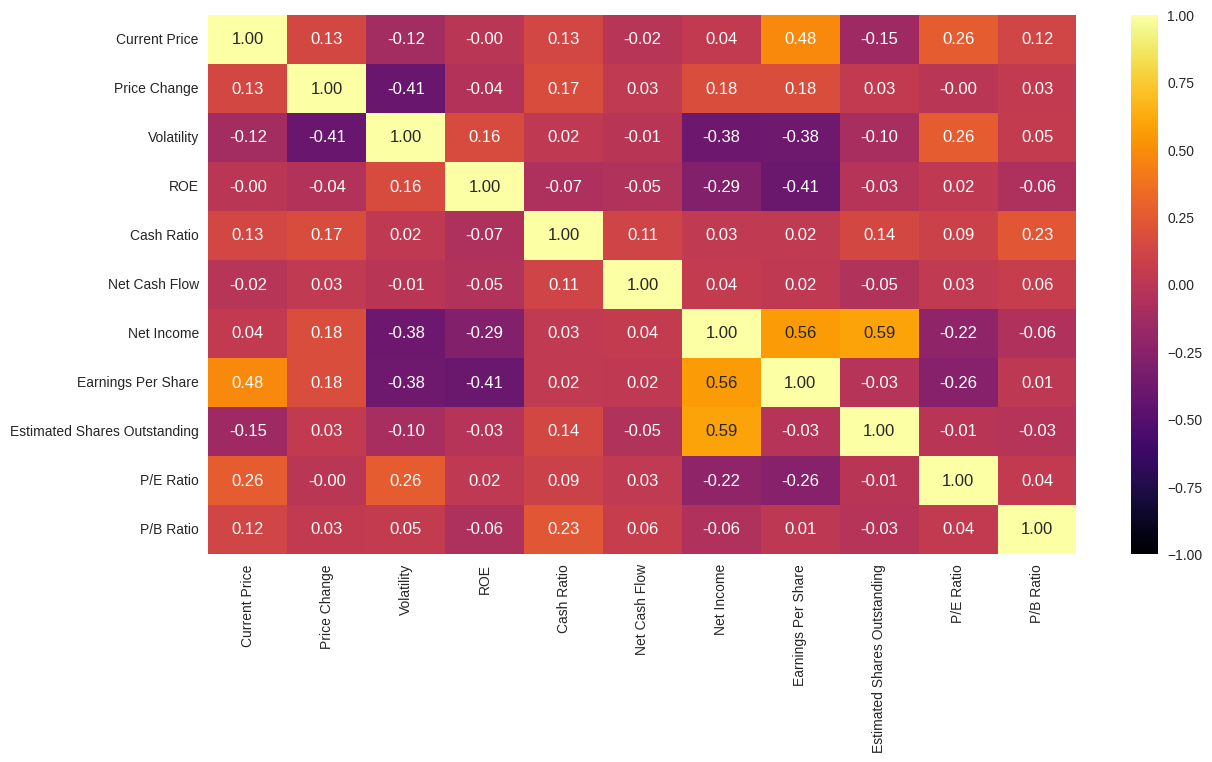

In [16]:
#create correlation heat map for numerical variables
plt.figure(figsize=(14, 7))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    cmap='inferno'
)
plt.show()

**Jonathan's Comments:** 

- Price Change and Volatility are negatively correlated, this means that the price change will drop if the stock is more volatile
- Net Income and Volatility are negatively correlated, this means that if the company have more Net Income the volatility of the stock will be lesser
- Net Income and Earning per share are positively correlated, this means that with higher Net Income the earning per share will be better
- Earning per share and current price are positively correlated, this means that a person will have more profit if the stock price increase, this is expected

## 4. Cash ratio provides a measure of a company's ability to cover its short-term obligations using only cash and cash equivalents. How does the average cash ratio vary across economic sectors?

In [17]:
df.groupby('GICS Sector')['Cash Ratio'].mean().sort_values(ascending=False)

GICS Sector
Information Technology        149.82
Telecommunications Services   117.00
Health Care                   103.78
Financials                     98.59
Consumer Staples               70.95
Energy                         51.13
Real Estate                    50.11
Consumer Discretionary         49.58
Materials                      41.70
Industrials                    36.19
Utilities                      13.62
Name: Cash Ratio, dtype: float64

**Jonathan's Comments:** 

- IT and Telecommunications sectors have the higher cash ratios, this means that companies in those sectors cover easily the short-term obligations meanwhile companies on Industrials and Utilities sector need to do much effort since their cash ratios are significant lower 

## 5. P/E ratios can help determine the relative value of a company's shares as they signify the amount of money an investor is willing to invest in a single share of a company per dollar of its earnings. How does the P/E ratio vary, on average, across economic sectors?

In [18]:
df.groupby('GICS Sector')['P/E Ratio'].mean().sort_values(ascending=False)

GICS Sector
Energy                        72.90
Information Technology        43.78
Real Estate                   43.07
Health Care                   41.14
Consumer Discretionary        35.21
Consumer Staples              25.52
Materials                     24.59
Utilities                     18.72
Industrials                   18.26
Financials                    16.02
Telecommunications Services   12.22
Name: P/E Ratio, dtype: float64

**Jonathan's Comments:** 

- Energy Sector have the best P/E ratio on average with a huge margin against other sectors

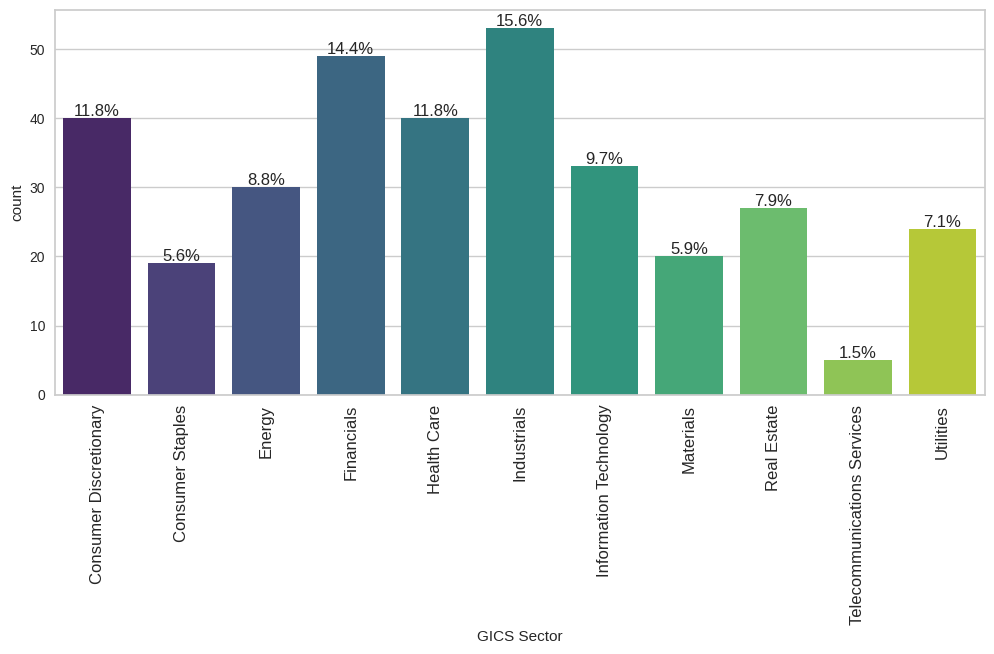

In [19]:
labeled_barplot(df, 'GICS Sector',perc=True)

**Jonathan's Comments:** 

- Top Five of stocks by sector are
    
    * Industrials 15.05%
    * Financials 14.4%
    * Health Care & Consumer Discretionary with 11.8%
    * Information Technology 9.7%
    * Energy 8.8%
    

## Data Preprocessing

- Duplicate value check

  Jonathan's Comment's: As was shown there is not duplicated values   
  
- Missing value treatment

  Jonathan's Comment's: As was shown there is not missing values to be treated  
    
- Outlier check

  Jonathan's Comment's: We are assuming that the info on the dataset are real data points

### Scaling the data

In order to have all features in the same scale and perform a correct analysis let's scale the data:

In [20]:
# Scaling the data set before clustering
scaler = StandardScaler()
subset = df[num_cols].copy()
subset_scaled = scaler.fit_transform(subset)

In [21]:
#create a dataframe from the scaled data
subset_scaled_df = pd.DataFrame(subset_scaled, columns=subset.columns)

In [22]:
subset_scaled_df.sample(n=5,random_state=1)

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
102,-0.50,-1.63,2.37,1.72,-0.00,0.40,-4.05,-5.83,-0.20,1.37,0.25
125,0.24,1.01,-0.35,-0.33,9.83,0.28,0.55,-0.22,2.63,1.07,0.55
11,-0.42,0.29,-0.61,-0.26,-0.26,-0.02,-0.32,-0.19,-0.49,-0.14,0.03
248,-0.01,0.55,-1.22,-0.23,0.65,0.05,-0.22,0.08,-0.10,-0.19,-0.04
238,-0.14,-0.27,0.11,-0.08,-0.07,-0.33,-2.37,-1.98,0.22,1.37,0.36


**Jonathan's Comments:** 

- Data has been scaled and we can follow with the next steps

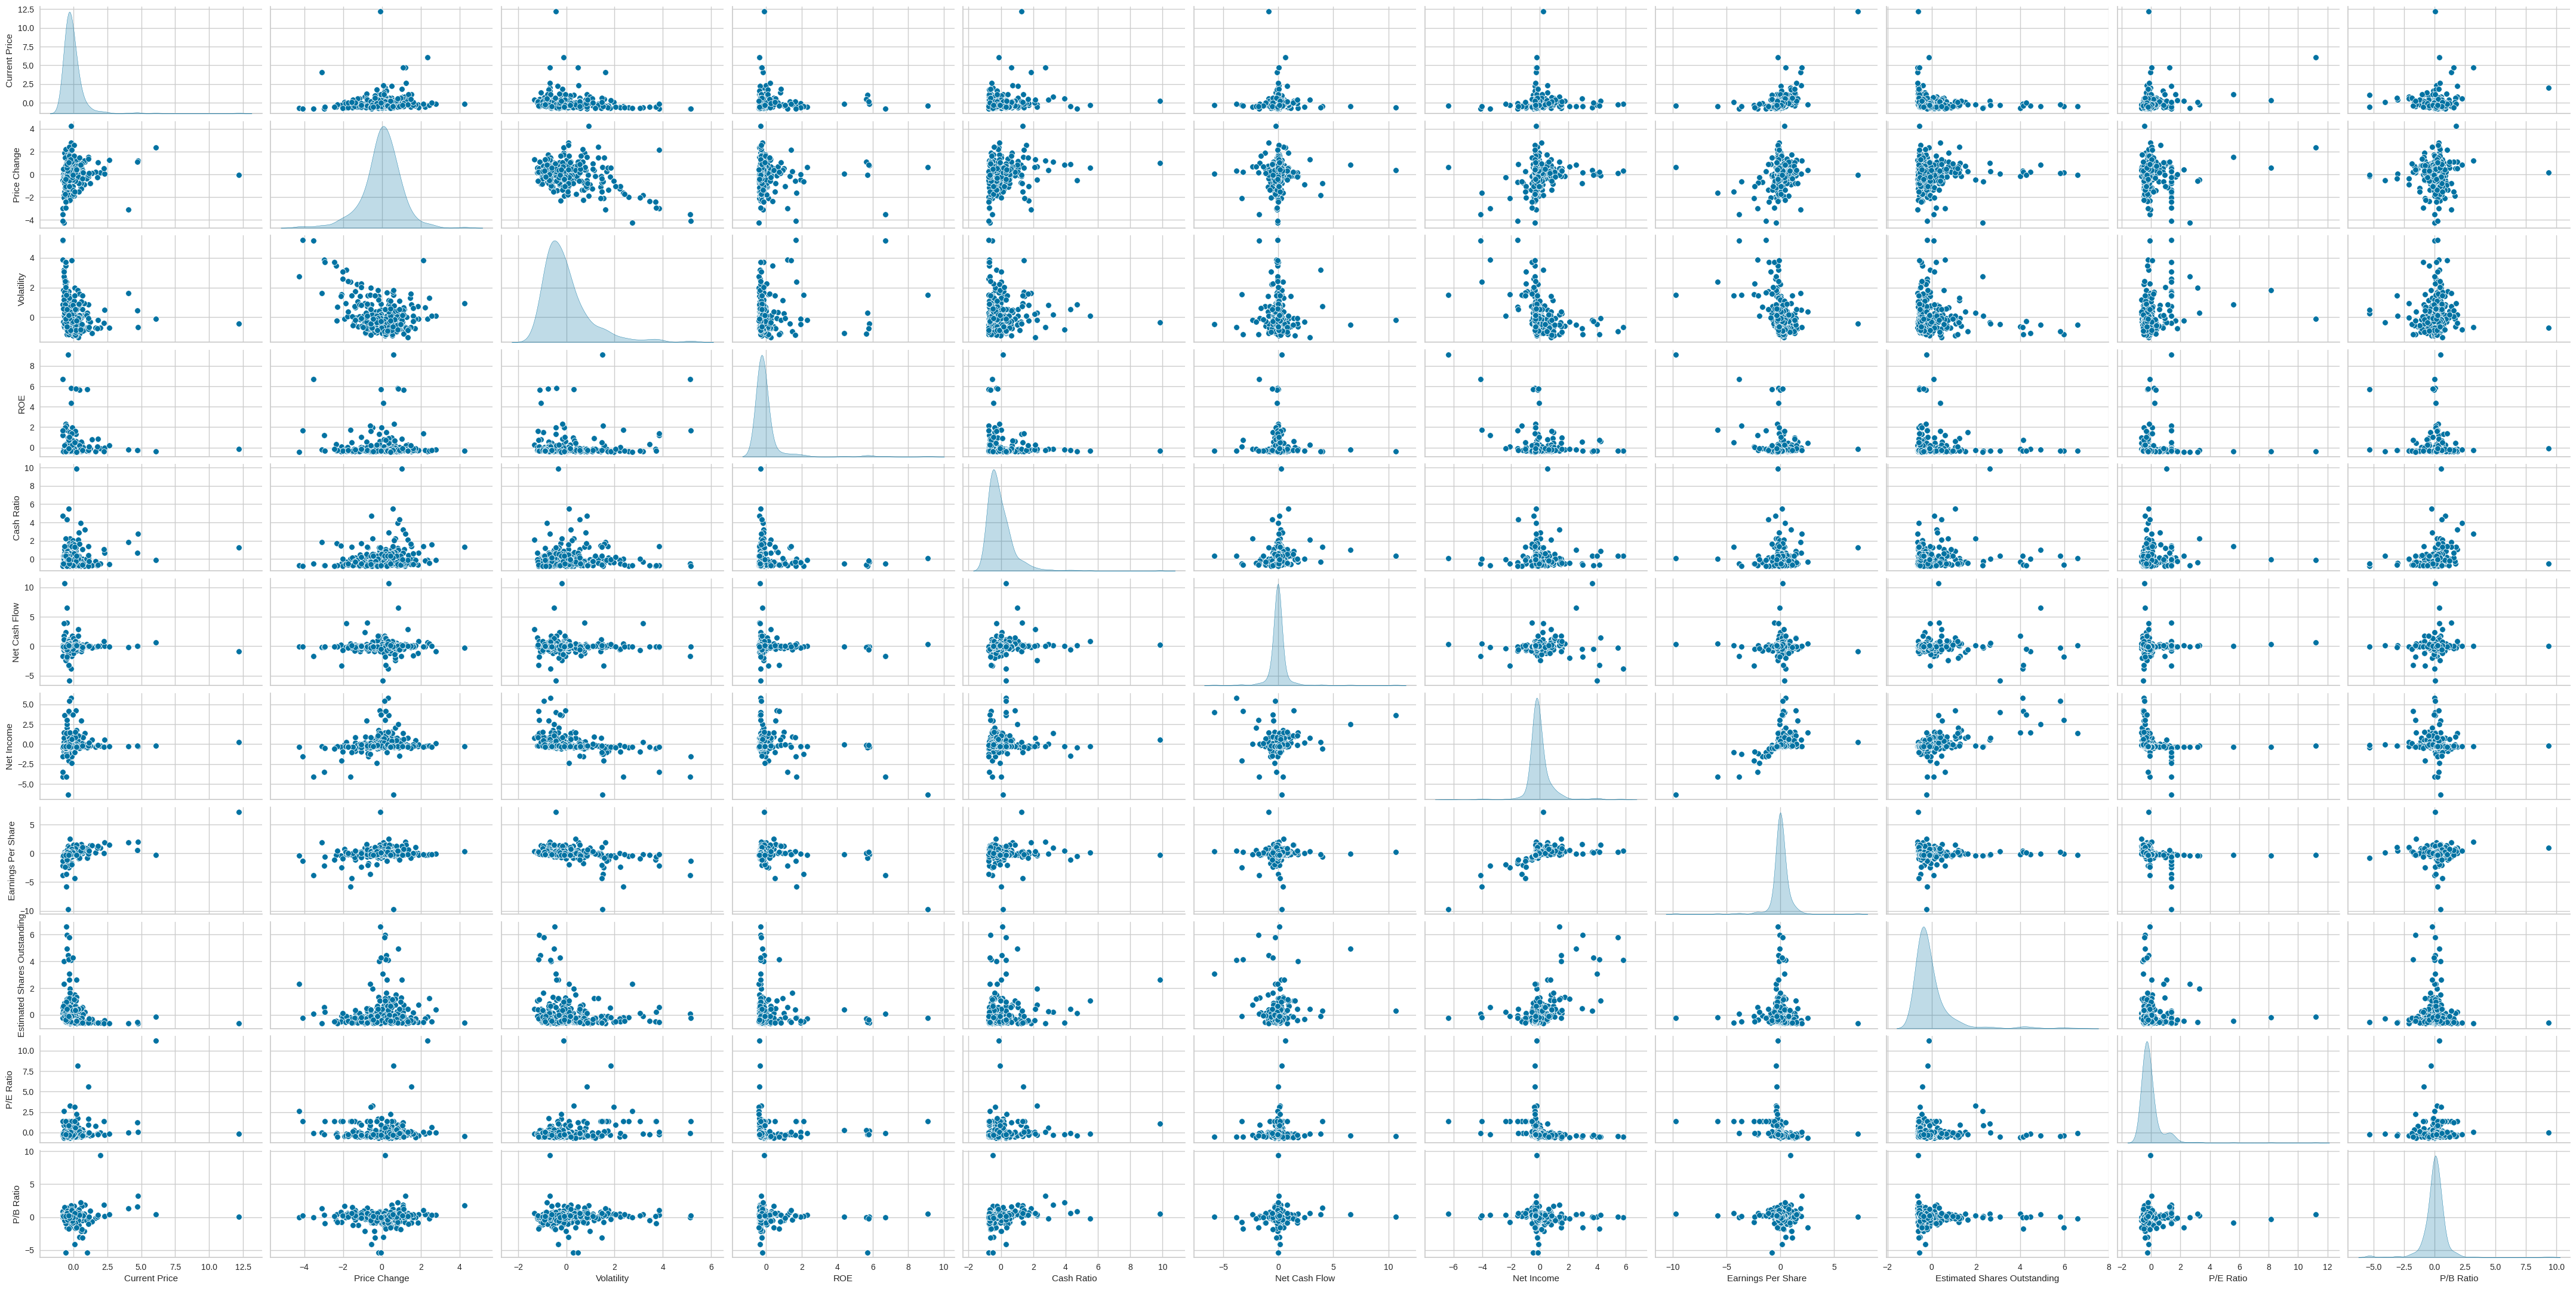

In [23]:
#create pairplot for scaled dataframe
sns.pairplot(subset_scaled_df, height=2,aspect=2 , diag_kind='kde')
plt.show()

## K-means Clustering

In [24]:
clusters = range(1, 11)
meanDistortions = []

for k in clusters:
    model = KMeans(n_clusters=k)
    model.fit(subset_scaled_df)
    prediction = model.predict(subset_scaled_df)
    distortion = (
        sum(
            np.min(cdist(subset_scaled_df, model.cluster_centers_, "euclidean"), axis=1)
        )
        / subset_scaled_df.shape[0]
    )

    meanDistortions.append(distortion)

    print("Number of Clusters:", k, "\tAverage Distortion:", distortion)

Number of Clusters: 1 	Average Distortion: 2.5425069919221697
Number of Clusters: 2 	Average Distortion: 2.3862098789299604
Number of Clusters: 3 	Average Distortion: 2.2659355306126447
Number of Clusters: 4 	Average Distortion: 2.1814875477097746
Number of Clusters: 5 	Average Distortion: 2.1235822571521346
Number of Clusters: 6 	Average Distortion: 2.072769863902725
Number of Clusters: 7 	Average Distortion: 2.0156803260709855
Number of Clusters: 8 	Average Distortion: 1.9660865046240923
Number of Clusters: 9 	Average Distortion: 1.9261559016350198
Number of Clusters: 10 	Average Distortion: 1.8899290594128038


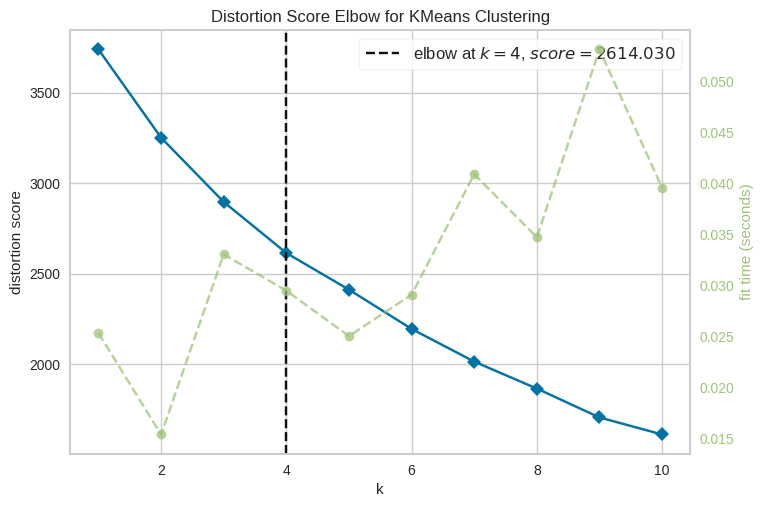

In [25]:
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(1, 11), timings=True)
visualizer.fit(subset_scaled_df)  # fit the data to the visualizer
visualizer.show()  # finalize and render figure
plt.show()

For n_clusters = 2, the silhouette score is 0.43969639509980457)
For n_clusters = 3, the silhouette score is 0.45797710447228496)
For n_clusters = 4, the silhouette score is 0.45017906939331087)
For n_clusters = 5, the silhouette score is 0.4599352800740646)
For n_clusters = 6, the silhouette score is 0.3985379248608659)
For n_clusters = 7, the silhouette score is 0.3868475076242907)
For n_clusters = 8, the silhouette score is 0.3886929719130642)
For n_clusters = 9, the silhouette score is 0.40581042332267614)
For n_clusters = 10, the silhouette score is 0.18011528994705786)


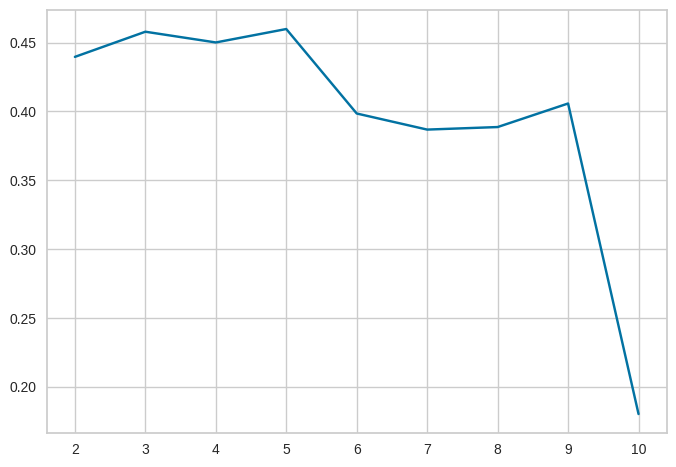

In [26]:
sil_score = []
cluster_list = range(2, 11)
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters, random_state=42)
    preds = clusterer.fit_predict((subset_scaled_df))
    score = silhouette_score(subset_scaled_df, preds)
    sil_score.append(score)
    print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score))

#show scores in line graph
plt.plot(cluster_list, sil_score)
plt.show()

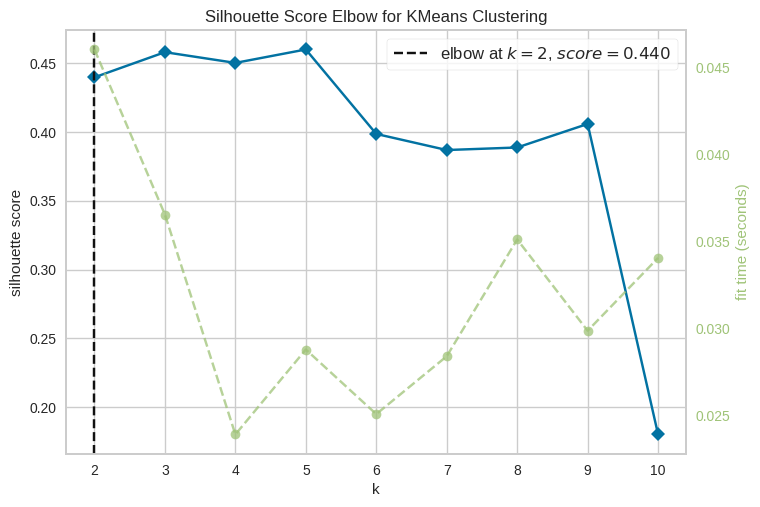

In [27]:
#fit KMeans model and use visualizaer to indicate optimal K value
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(2, 11), metric="silhouette", timings=True)
visualizer.fit(subset_scaled_df)  # fit the data to the visualizer
visualizer.show()  # finalize and render figure
plt.show()

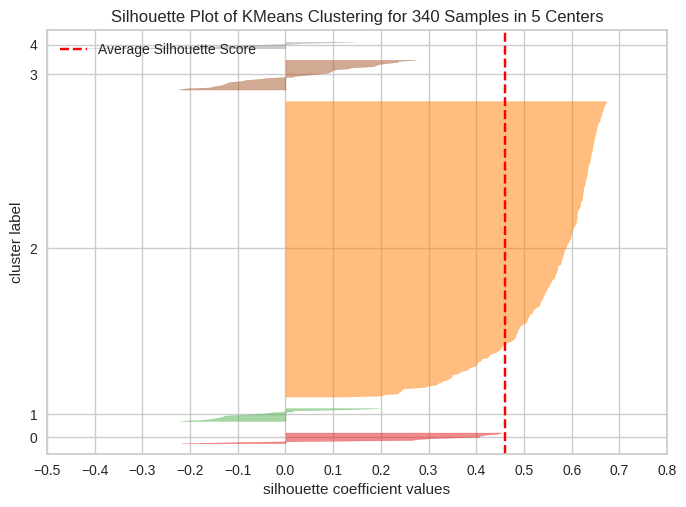

In [28]:
#find optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(5, random_state=42))
visualizer.fit(subset_scaled_df)
visualizer.show()
plt.show()

**Jonathan's Comments:** 

- Accordingly with the Elbow and Silhouette plots lets choose 5 as number of clusters

In [29]:
#create kmeans cluster model
kmeans = KMeans(n_clusters=5, random_state=42)

#fit model to scaled dataset
kmeans.fit(subset_scaled_df)

KMeans(n_clusters=5, random_state=42)

#### Cluster Profiling

In [31]:
# adding kmeans cluster labels to the original dataframe
df["KMeans_clusters"] = kmeans.labels_

In [32]:
# adding kmeans cluster labels to the original dataframe
df["KMeans_clusters"] = kmeans.labels_

In [33]:
#group dataset by kmeans cluster labels
cluster_profile = df.groupby("KMeans_clusters").mean()

#add counts for number of stocks in each cluster
cluster_profile["Count"] = (
    df.groupby("KMeans_clusters")["Current Price"].count().values
)

In [34]:
cluster_profile

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,Count
KMeans_clusters,,,,,,,,,,,,
0,50.48,5.59,1.14,31.55,64.18,-2581727272.73,14675545454.55,4.49,4012176129.00,14.01,-5.36,11
1,81.42,10.54,1.58,17.00,367.54,3857062692.31,3129067846.15,2.20,1334755181.58,65.64,6.24,13
2,73.77,5.47,1.39,34.63,55.71,4183132.14,1443269353.57,3.63,430217149.04,24.13,-3.20,280
3,38.81,-13.68,2.94,106.03,55.55,-189825655.17,-3578126517.24,-8.66,463121182.88,85.95,1.89,29
4,585.53,7.75,1.51,17.57,159.14,210520428.57,804590428.57,14.41,116080574.76,118.76,33.71,7


Let's check the stock number by Industry:

In [36]:
for k in range(0,df['KMeans_clusters'].nunique()):
    print('The number of stocks within each GICS Sector for Cluster '+str(k)+' are:')
    print(df[df['KMeans_clusters']==k]['GICS Sector'].value_counts())
    print("   ")

The number of stocks within each GICS Sector for Cluster 0 are:
Financials                     3
Consumer Discretionary         2
Health Care                    2
Telecommunications Services    2
Consumer Staples               1
Energy                         1
Industrials                    0
Information Technology         0
Materials                      0
Real Estate                    0
Utilities                      0
Name: GICS Sector, dtype: int64
   
The number of stocks within each GICS Sector for Cluster 1 are:
Health Care                    4
Information Technology         4
Consumer Discretionary         1
Consumer Staples               1
Energy                         1
Financials                     1
Telecommunications Services    1
Industrials                    0
Materials                      0
Real Estate                    0
Utilities                      0
Name: GICS Sector, dtype: int64
   
The number of stocks within each GICS Sector for Cluster 2 are:
Industrial

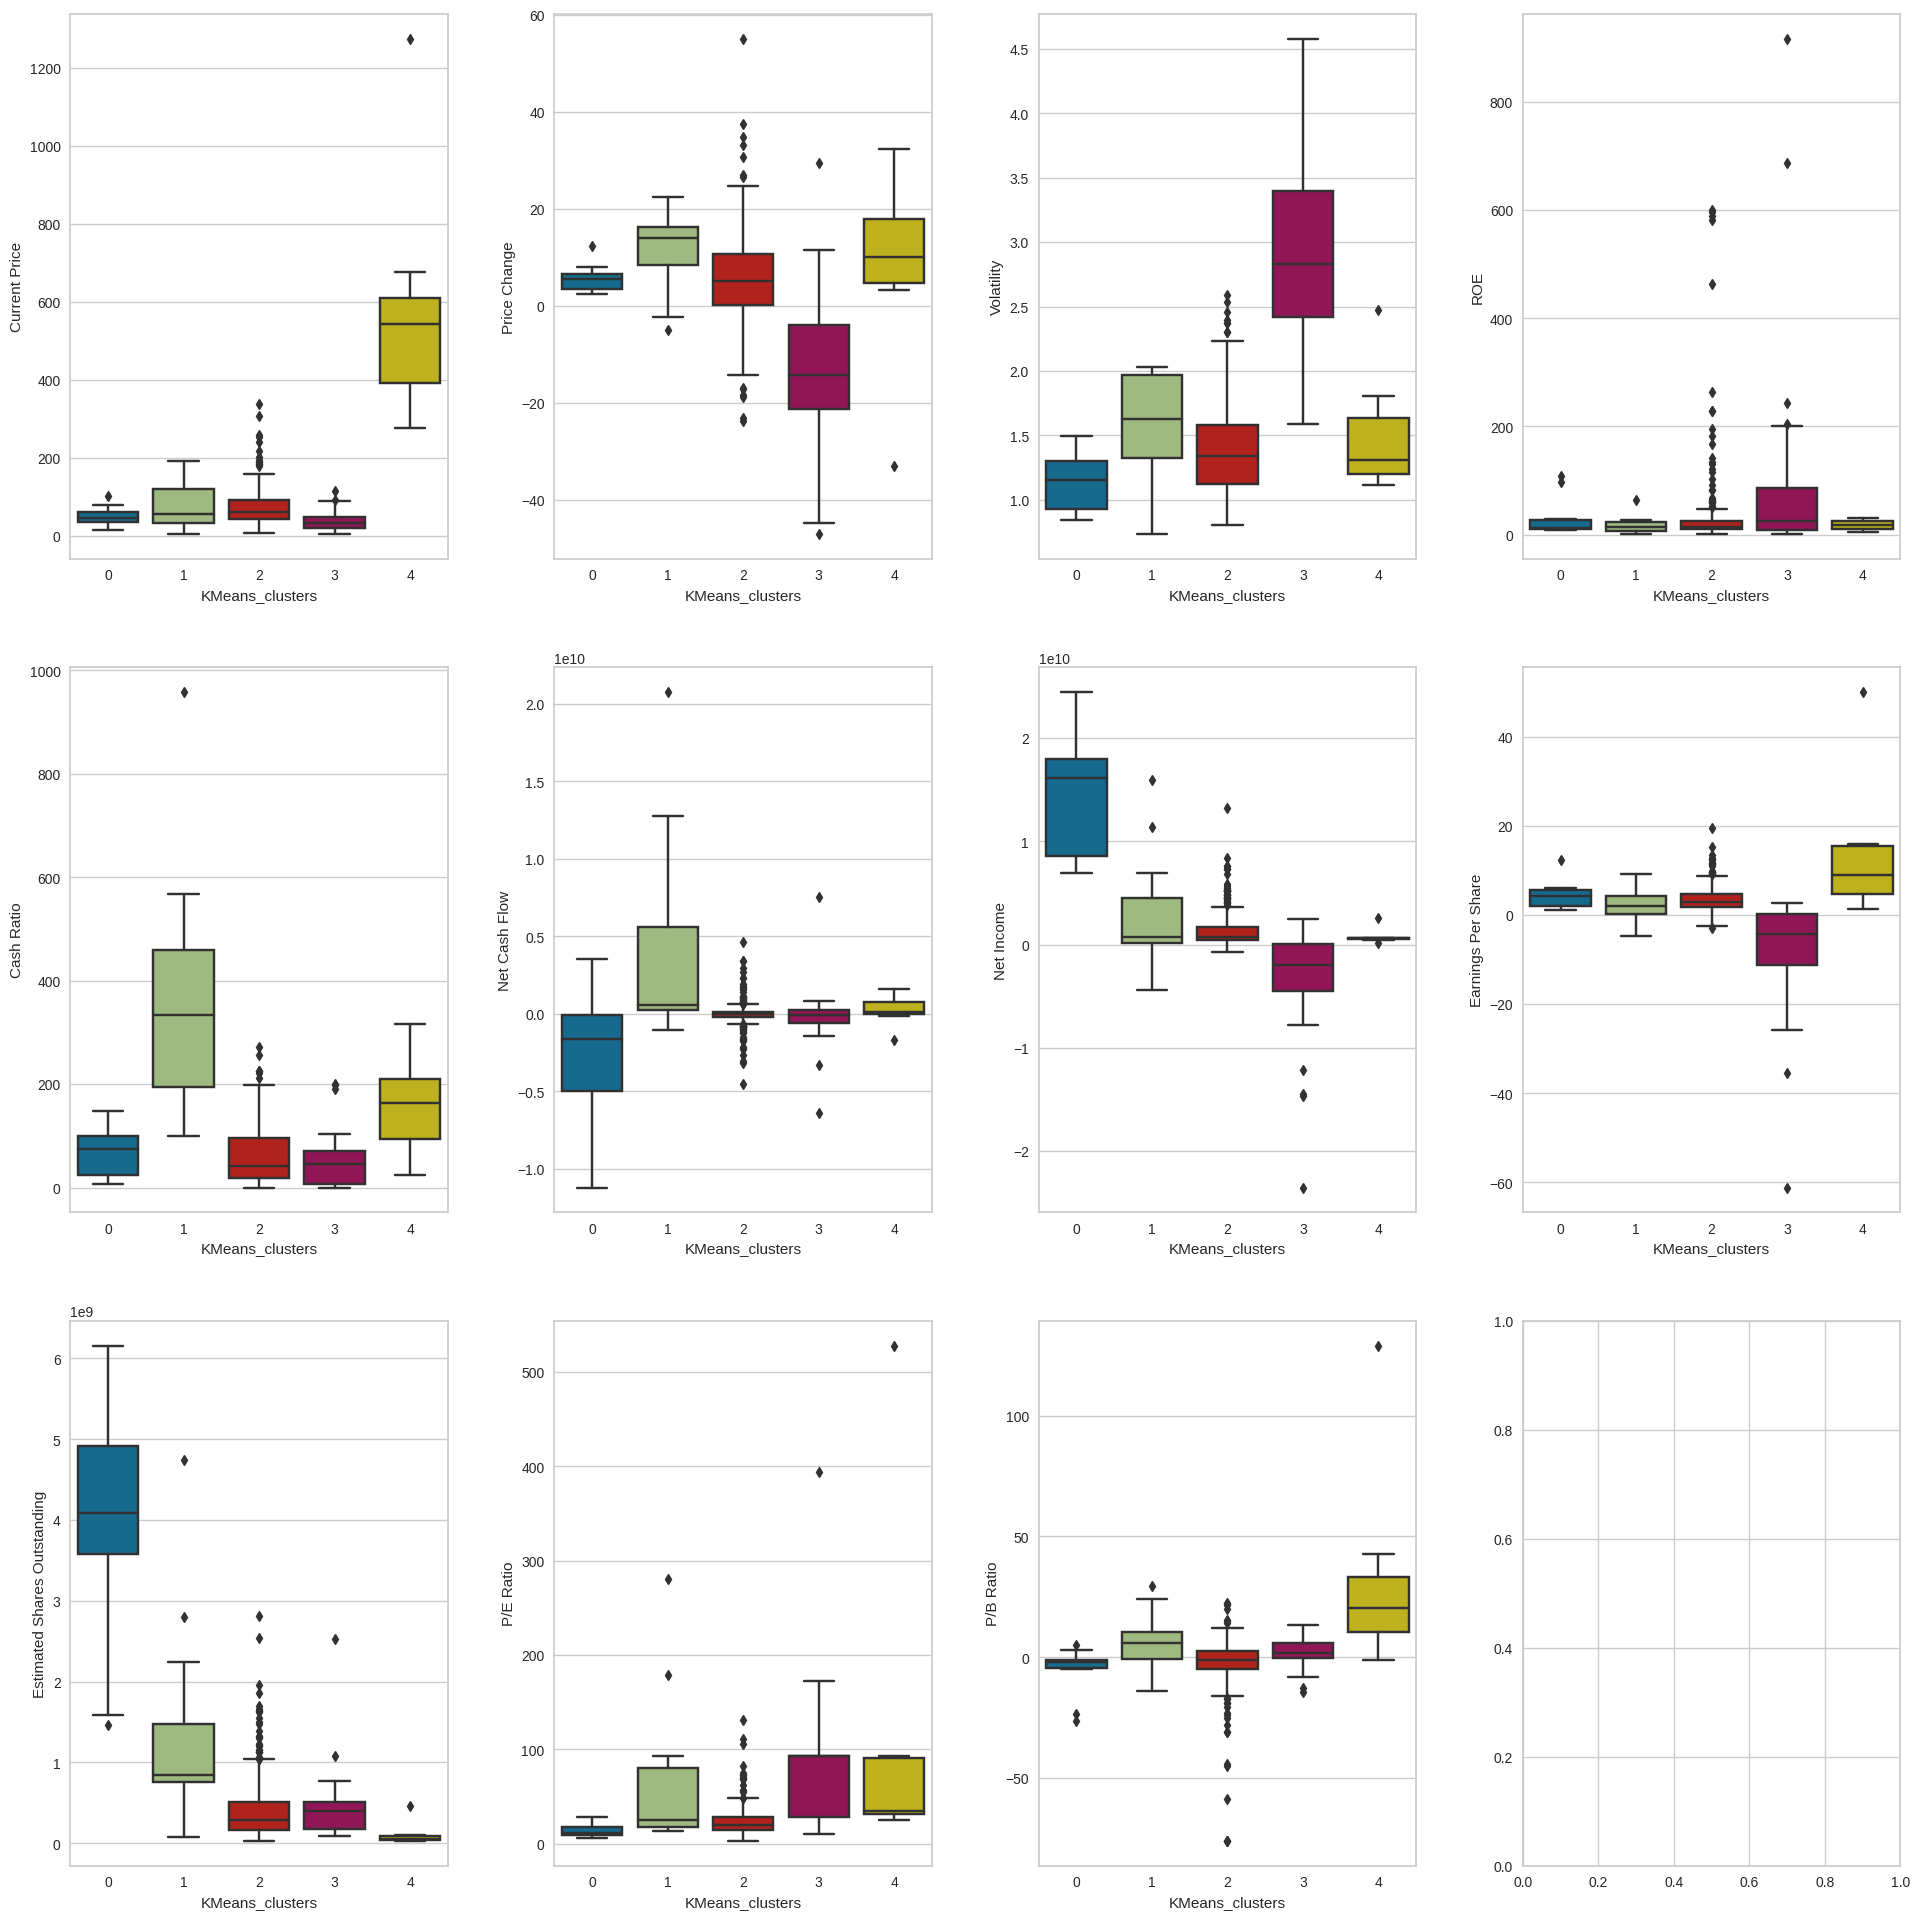

In [37]:
fig, axes = plt.subplots(3, 4, figsize=(20, 20))
counter = 0

for ii in range(3):
    for jj in range(4):
        if counter < 11:
            sns.boxplot(
                ax=axes[ii][jj],
                data=df,
                y=df.columns[3+counter],
                x="KMeans_clusters"
                
            )
            counter = counter + 1

fig.tight_layout(pad=3.0)

### Jonathan's Comments

### Cluster 0
    - Cluster with 11 stocks 
    - Top 3 GICS Sector on this cluster are 
        * Financials                     
        * Consumer Discretionary         
        * Health Care  
    - The cluster with lowest volatility compared with  other clusters
    - Highest Net income compared with other clusters 

### Cluster 1
    - Cluster with 13 stocks 
    - Top 3 GICS Sector on this cluster are 
        * Health Care                    
        * Information Technology 
        * Consumer Discretionary   
    - Higest Cash Ratio and Net Cash Flow compared with other clusters
    - Volatility moderated

### Cluster 2
    - Cluster with most number of stocks 280 in total
    - Top 3 GICS Sector on this cluster are 
            * Industrials                    
            * Financials                     
            * Consumer Discretionary         
    - Cluster with low P/E Ratios

### Cluster 3
    - Top 2 in terms of stock amount 29 in total 
    - Top 3 GICS Sector on this cluster are 
            * Energy                         
            * Information Technology          
            * Materials                          
    - Cluster with Highest Volatility 
    - Lowest price change compared with other clusters 
    - Lowest Earning per share

### Cluster 4
    - Cluster with the lowest stocks amount
    - Top 3 GICS Sector on this cluster are 
             * Consumer Discretionary         
             * Health Care                    
             * Information Technology                                
    - Cluster with Highest Prices compared with other clusters 
    - Highest earning per share

## Hierarchical Clustering

In [40]:
# list of distance metrics
distance_metrics = ["euclidean", "chebyshev", "mahalanobis", "cityblock"]

# list of linkage methods
linkage_methods = ["single", "complete", "average", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for dm in distance_metrics:
    for lm in linkage_methods:
        Z = linkage(subset_scaled_df, metric=dm, method=lm)
        c, coph_dists = cophenet(Z, pdist(subset_scaled_df))
        print(
            "Cophenetic correlation for {} distance and {} linkage is {}.".format(
                dm.capitalize(), lm, round(c,4)
            )
        )
        print(" ")
        if high_cophenet_corr < c:
            high_cophenet_corr = c
            high_dm_lm[0] = dm
            high_dm_lm[1] = lm

Cophenetic correlation for Euclidean distance and single linkage is 0.9232.
 
Cophenetic correlation for Euclidean distance and complete linkage is 0.7873.
 
Cophenetic correlation for Euclidean distance and average linkage is 0.9423.
 
Cophenetic correlation for Euclidean distance and weighted linkage is 0.8694.
 
Cophenetic correlation for Chebyshev distance and single linkage is 0.9063.
 
Cophenetic correlation for Chebyshev distance and complete linkage is 0.5989.
 
Cophenetic correlation for Chebyshev distance and average linkage is 0.9338.
 
Cophenetic correlation for Chebyshev distance and weighted linkage is 0.9127.
 
Cophenetic correlation for Mahalanobis distance and single linkage is 0.9259.
 
Cophenetic correlation for Mahalanobis distance and complete linkage is 0.7925.
 
Cophenetic correlation for Mahalanobis distance and average linkage is 0.9247.
 
Cophenetic correlation for Mahalanobis distance and weighted linkage is 0.8708.
 
Cophenetic correlation for Cityblock dist

In [41]:
# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print(
    "Highest cophenetic correlation is {}, which is obtained with {} distance and {} linkage.".format(
        round(high_cophenet_corr,4), high_dm_lm[0].capitalize(), high_dm_lm[1]
    )
)

Highest cophenetic correlation is 0.9423, which is obtained with Euclidean distance and average linkage.


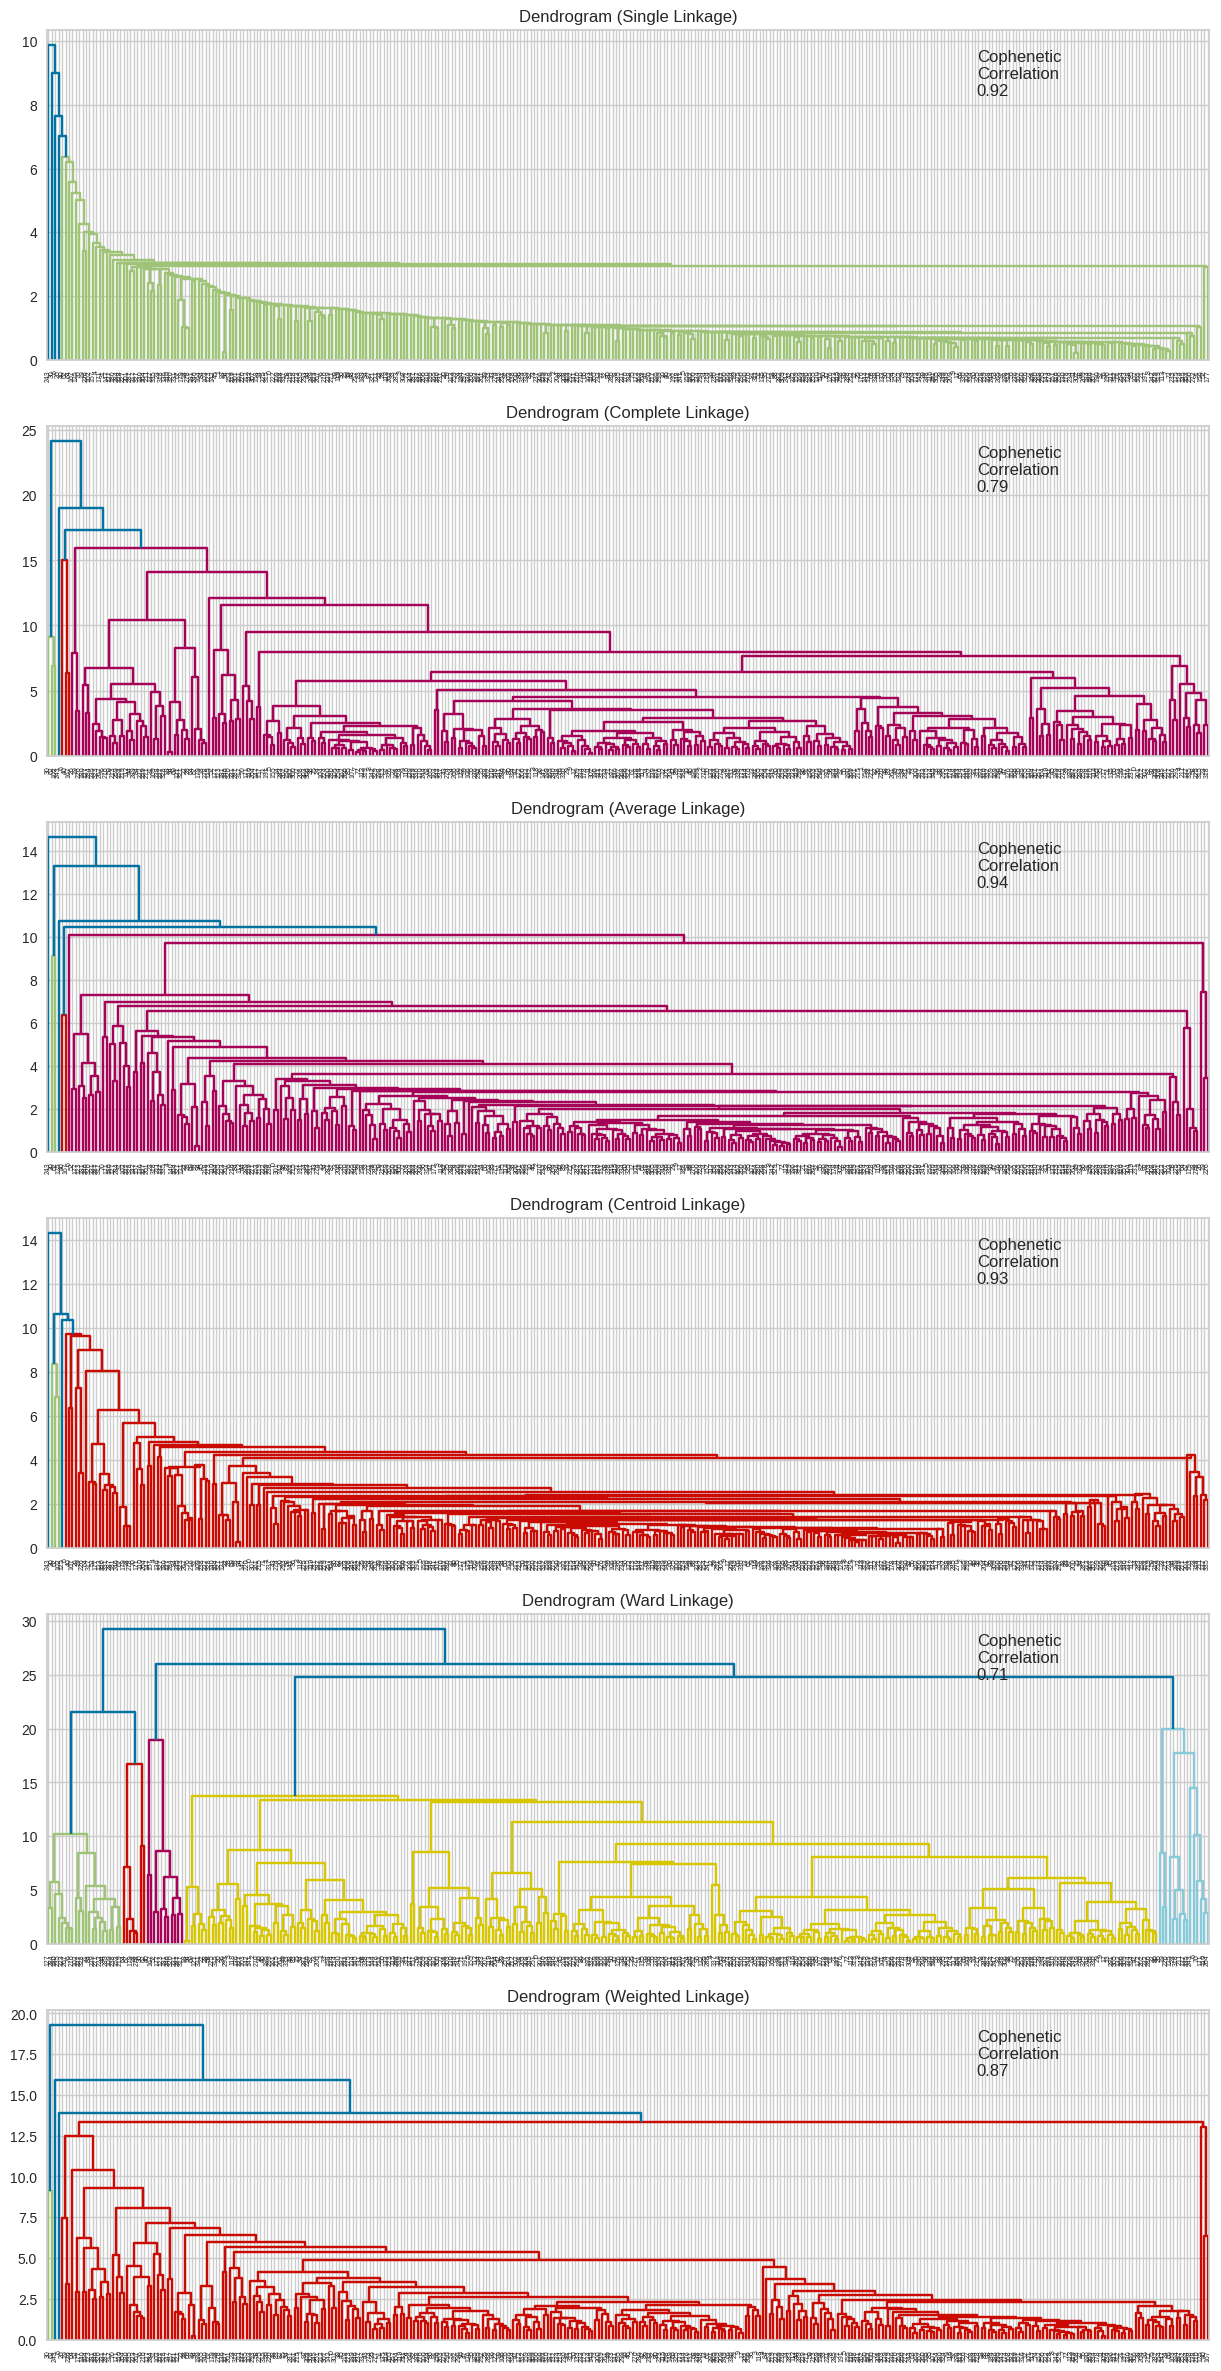

In [43]:
# list of linkage methods
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

# lists to save results of cophenetic correlation calculation
compare_cols = ["Linkage", "Cophenetic Coefficient"]

# to create a subplot image
fig, axs = plt.subplots(len(linkage_methods), 1, figsize=(15, 30))

# We will enumerate through the list of linkage methods above
# For each linkage method, we will plot the dendrogram and calculate the cophenetic correlation
for i, method in enumerate(linkage_methods):
    Z = linkage(subset_scaled_df, metric="euclidean", method=method)

    dendrogram(Z, ax=axs[i])
    axs[i].set_title(f"Dendrogram ({method.capitalize()} Linkage)")

    coph_corr, coph_dist = cophenet(Z, pdist(subset_scaled_df))
    axs[i].annotate(
        f"Cophenetic\nCorrelation\n{coph_corr:0.2f}",
        (0.80, 0.80),
        xycoords="axes fraction",
    )

### Jonathan's Comments:
    - The best Cophenetic correlation are represented by centroid and average linkage methods 
    - Accordingly with the average dendrogram this provides better clusters
    - Let's choose 5 as optimal number for average linkage method

In [44]:
Z = linkage(subset_scaled_df, metric='euclidean', method='average')
c, coph_dists = cophenet(Z , pdist(subset_scaled_df))

In [45]:
hierarchy = AgglomerativeClustering(n_clusters=5, affinity='euclidean',  linkage='average')
hierarchy.fit(subset_scaled_df)

AgglomerativeClustering(linkage='average', n_clusters=5)

#### Cluster Profiling

In [46]:
df_hierarchy = df.copy()
df_hierarchy.drop("KMeans_clusters", axis=1, inplace=True)
df_hierarchy['HC_clusters'] = hierarchy.labels_

In [48]:
#group dataset by Hierarchical clusters
cluster_profile_h = df_hierarchy.groupby("HC_clusters").mean()

#add counts for number of stocks in each cluster
cluster_profile_h["Count"] = (
    df_hierarchy.groupby("HC_clusters")["Current Price"].count().values
)

cluster_profile_h

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,Count
HC_clusters,,,,,,,,,,,,
0,77.88,4.11,1.52,35.32,66.78,-32825817.37,1535255703.59,2.90,559027333.15,32.44,-1.78,334
1,25.64,11.24,1.32,12.50,130.50,16755500000.00,13654000000.00,3.29,2791829362.10,13.65,1.51,2
2,24.49,-13.35,3.48,802.00,51.00,-1292500000.00,-19106500000.00,-41.81,519573983.25,60.75,1.57,2
3,104.66,16.22,1.32,8.00,958.00,592000000.00,3669000000.00,1.31,2800763359.00,79.89,5.88,1
4,1274.95,3.19,1.27,29.00,184.00,-1671386000.00,2551360000.00,50.09,50935516.07,25.45,-1.05,1


##### Jonathan's Comments: There is not good variability, let's try using ward linkage method with 5 clusters

In [49]:
HCmodel = AgglomerativeClustering(n_clusters=5, affinity="euclidean", linkage="ward")
HCmodel.fit(subset_scaled_df)

AgglomerativeClustering(n_clusters=5)

In [50]:
subset_scaled_df["HC_clusters"] = HCmodel.labels_
df_hierarchy["HC_clusters"] = HCmodel.labels_

In [51]:
#group dataset by Hierarchical clusters
cluster_profile_h = df_hierarchy.groupby("HC_clusters").mean()

#add counts for number of stocks in each cluster
cluster_profile_h["Count"] = (
    df_hierarchy.groupby("HC_clusters")["Current Price"].count().values
)

#show dataframe with maximum values for each metric highlighted
cluster_profile_h

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,Count
HC_clusters,,,,,,,,,,,,
0,326.20,10.56,1.64,14.40,309.47,288850666.67,864498533.33,7.79,544900261.30,113.10,19.14,15
1,84.36,3.85,1.83,633.57,33.57,-568400000.00,-4968157142.86,-10.84,398169036.44,42.28,-11.59,7
2,42.85,6.27,1.12,22.73,71.45,558636363.64,14631272727.27,3.41,4242572567.29,15.24,-4.92,11
3,72.76,5.21,1.43,25.60,60.39,79951512.28,1538594322.81,3.66,446472132.23,24.72,-2.65,285
4,36.44,-16.07,2.83,57.50,42.41,-472834090.91,-3161045227.27,-8.00,514367806.20,85.56,0.84,22


##### Jonathan's Comments: We have better variability

In [52]:
# print the number of stocks in each GICS sector for each cluster
for k in range(0,df_hierarchy['HC_clusters'].nunique()):
    print('The number of stocks within each GICS Sector for Cluster '+str(k)+' are:')
    print(df_hierarchy[df_hierarchy['HC_clusters']==k]['GICS Sector'].value_counts())
    print("   ")

The number of stocks within each GICS Sector for Cluster 0 are:
Health Care                    5
Information Technology         4
Consumer Discretionary         3
Consumer Staples               1
Real Estate                    1
Telecommunications Services    1
Energy                         0
Financials                     0
Industrials                    0
Materials                      0
Utilities                      0
Name: GICS Sector, dtype: int64
   
The number of stocks within each GICS Sector for Cluster 1 are:
Consumer Staples               2
Energy                         2
Consumer Discretionary         1
Financials                     1
Industrials                    1
Health Care                    0
Information Technology         0
Materials                      0
Real Estate                    0
Telecommunications Services    0
Utilities                      0
Name: GICS Sector, dtype: int64
   
The number of stocks within each GICS Sector for Cluster 2 are:
Financials

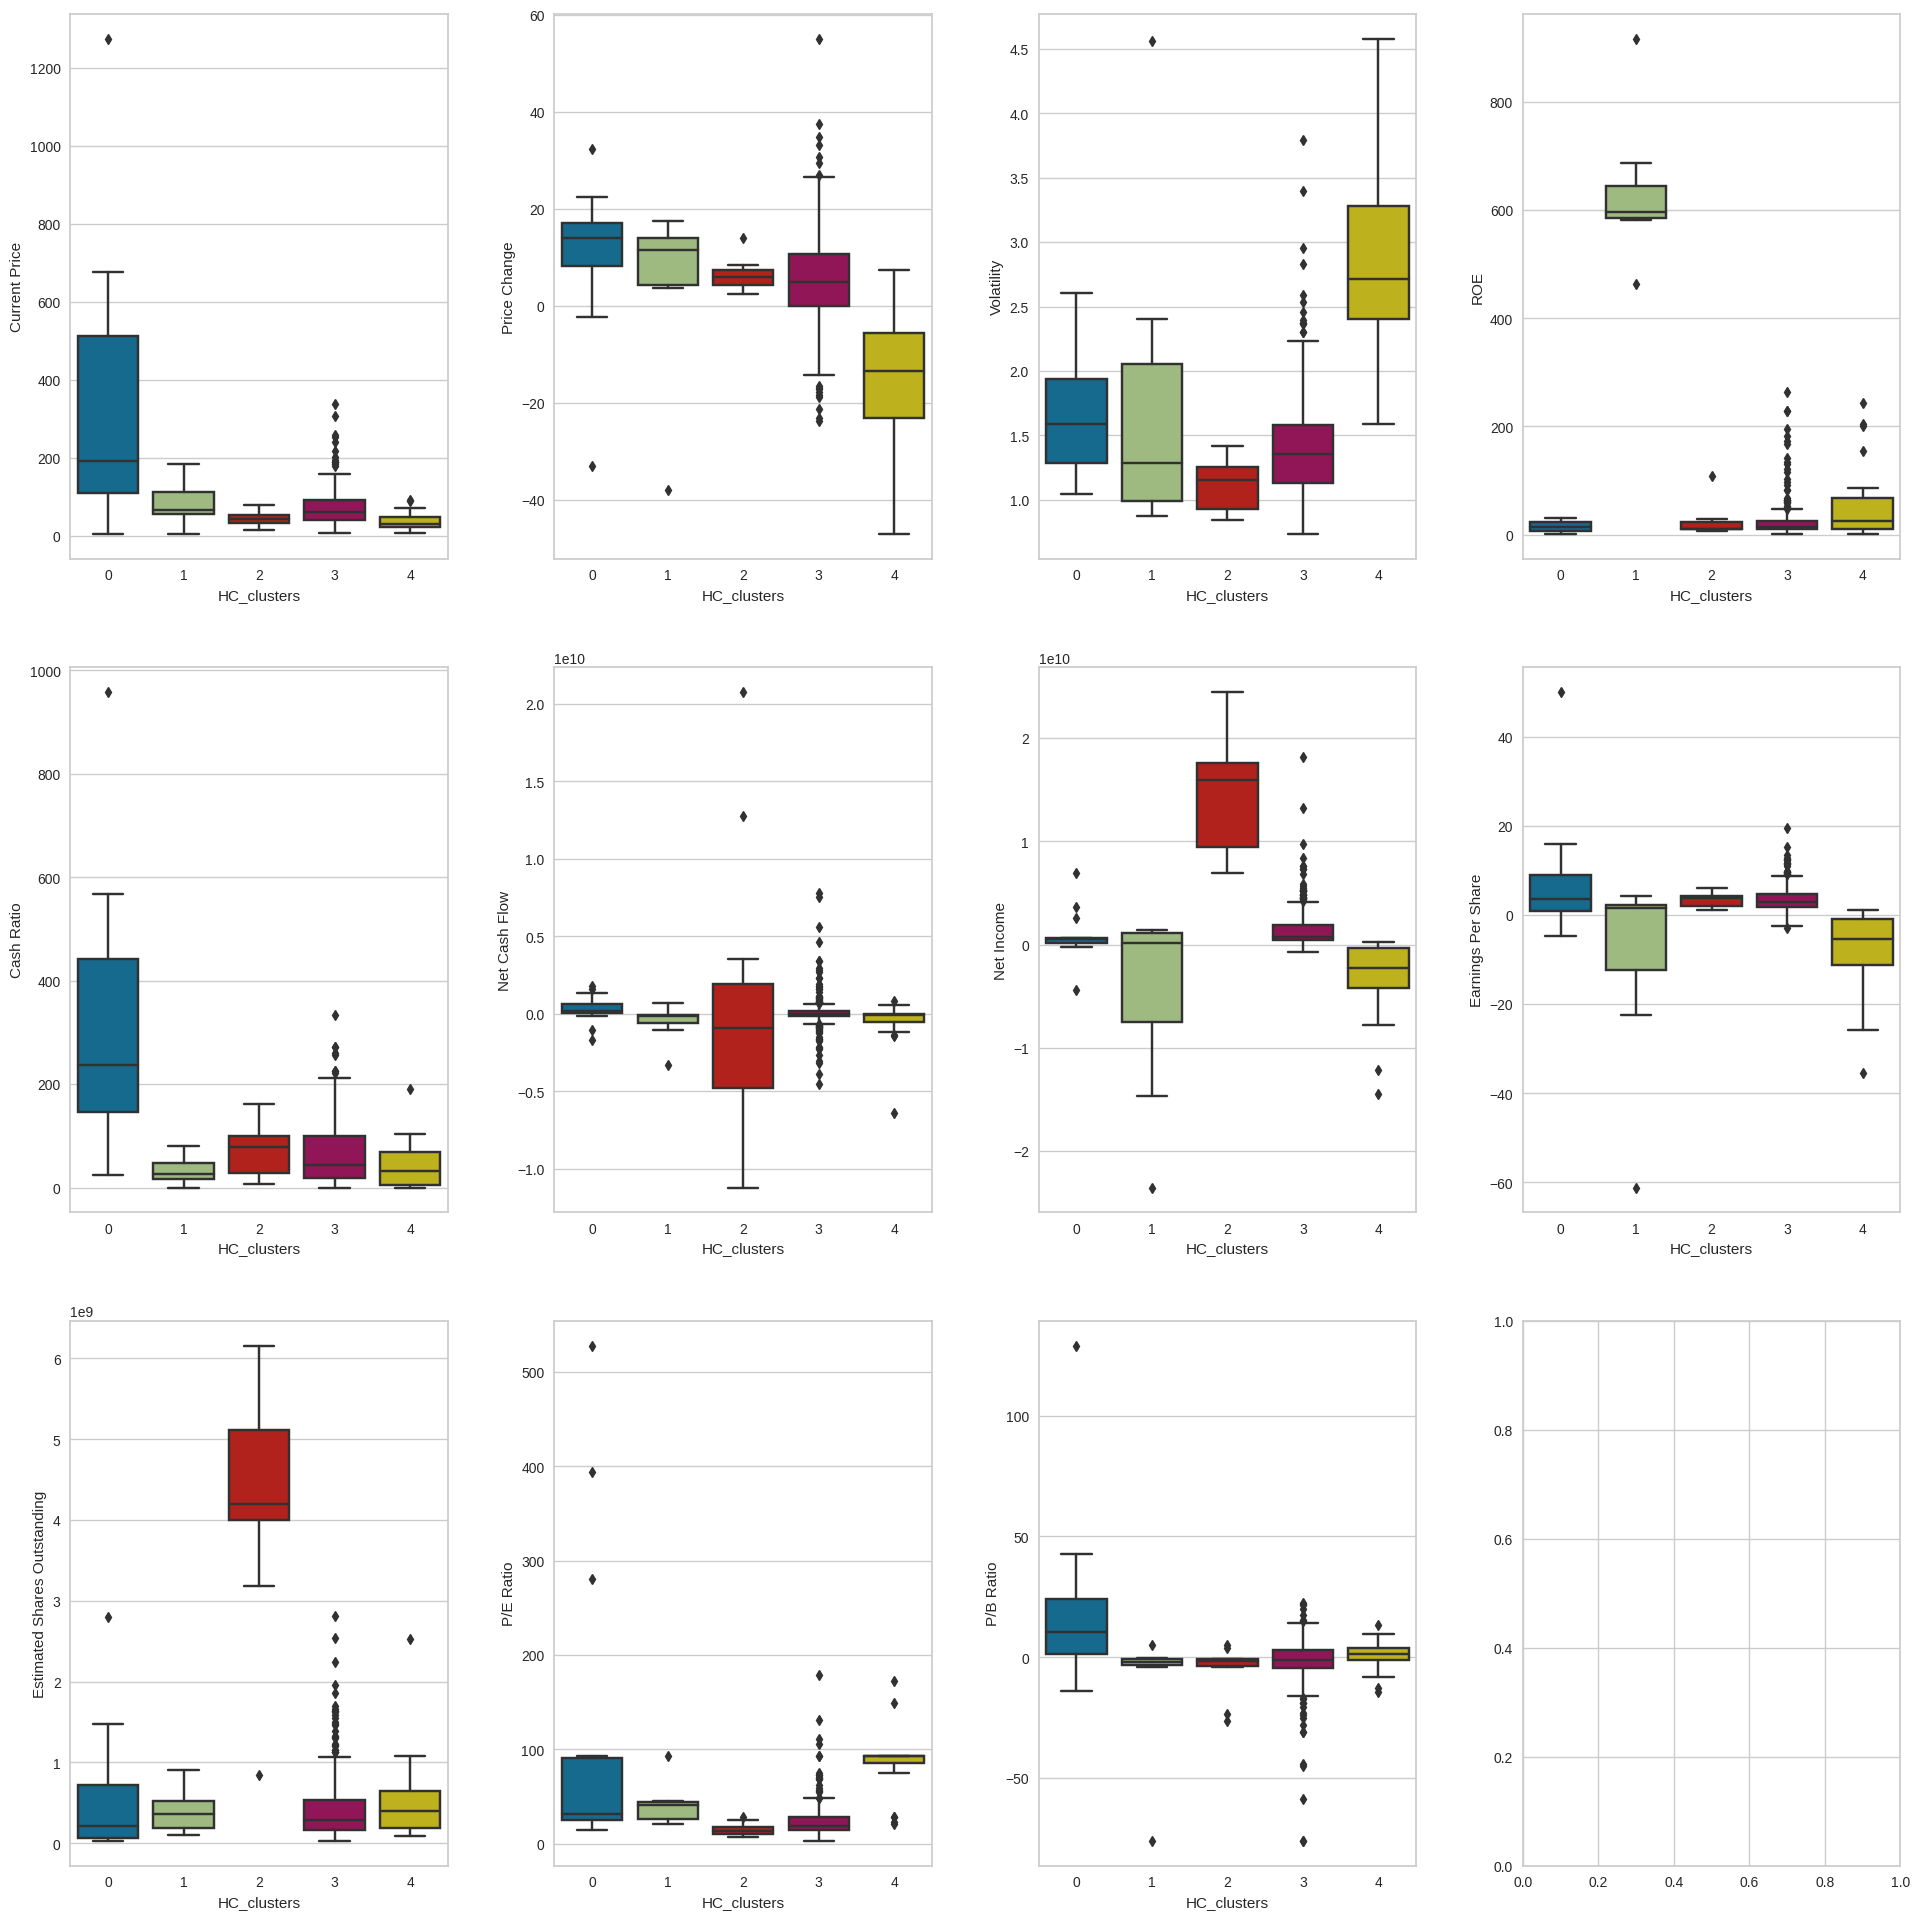

In [53]:
# show boxplots of numerical variables for each Hierarchical cluster
fig, axes = plt.subplots(3, 4, figsize=(20, 20))
counter = 0

for ii in range(3):
    for jj in range(4):
        if counter < 11:
            sns.boxplot(
                ax=axes[ii][jj],
                data=df_hierarchy,
                y=df_hierarchy.columns[3+counter],
                x="HC_clusters",                
            )
            counter = counter + 1

fig.tight_layout(pad=3.0)

### Cluster 0
    - Cluster with 15 stocks 
    - Top 3 GICS Sector on this cluster are 
            * Health Care                    
            * Information Technology         
            * Consumer Discretionary         
    - The cluster with highest price compared with  other clusters

### Cluster 1
    - Cluster with lowest amount of stocks 7
    - Top 3 GICS Sector on this cluster are 
             * Consumer Staples               
             * Energy                         
             * Consumer Discretionary                  
    - Low Earning per share 
    - Lowest Net Income

### Cluster 2
    - Cluster with 11 stocks in total 
    - Top 3 GICS Sector on this cluster are 
             * Financials                     
             * Telecommunications Services    
             * Consumer Discretionary                        
    - The Highest Net Income 
    - The highest number of shares outstanding

### Cluster 3
    - Cluster major number of stocks 285 in total
    - Top 3 GICS Sector on this cluster are 
            * Industrials                    
            * Financials                     
            * Consumer Discretionary                          
    - Cluster characterized to have outliers 

### Cluster 4
    - Cluster with 22 stocks in total
    - Top 3 GICS Sector on this cluster are 
            * Energy                         
            * Information Technology          
            * Materials                                               
    - Cluster characterized to have majority stock of Energy sector

## K-means vs Hierarchical Clustering

You compare several things, like:
- Which clustering technique took less time for execution?
  
  **Jonathan's comment: - Both the KMeans model and the Agglomerative Clustering model fit the dataset within ~0.1s**

- Which clustering technique gave you more distinct clusters, or are they the same?

    **Jonathan's comment:not exactly the same but are similar the clusters obtained from both techniques**
    
- How many observations are there in the similar clusters of both algorithms?  
    
    **Jonathan's Comment: 
     
- How many clusters are obtained as the appropriate number of clusters from both algorithms?

    **Jonathan's comment: Both algorithms resulted in the formation of 5 distinct clusters, each containing a sufficient number of observations to allow for the identification of the specific "type" of stock represented by the cluster.**

You can also mention any differences or similarities you obtained in the cluster profiles from both the clustering techniques.

## Actionable Insights and Recommendations

- To provide personalized investment recommendations, Trade&Ahead should first assess their clients' financial goals, risk tolerance, and investment behaviors. Based on this information, they could suggest a cluster of stocks as a 
- Alternatively, Trade&Ahead could use these clusters as a starting point for further financial analysis to identify individual stocks that do not fit the "profile" of the cluster.
- If selecting individual stocks is part of the client's investment strategy, Trade&Ahead could potentially recommend buying or selling certain stocks based on their expected performance relative to their peers.